# Diversity-aware ensemble-pooled refinement

This paired experiment tests the new feature- and prediction-diversity terms
at temperature 0.05. It starts from the no-holdout five-member forward-knee
ensemble and uses feature-diversity weight 0.2, prediction-diversity weight
0.1, performance tolerance 0.02, maximum pairwise feature similarity 0.8,
500 maximum steps, patience 50, and cooling rate 0.97.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.0
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            reduction_factor=0,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
history_rows = []
strategy = "forward_knee"
num_models = 5
max_steps = 500
temperature = 0.05
feature_diversity_weight = 0.2
prediction_diversity_weight = 0.1
performance_tolerance = 0.02
max_feature_similarity = 0.8

for seed in INNER_SEEDS:
    scaler, base_ensemble, knee_count = fit_knee_ensemble(
        strategy, num_models, seed
    )
    rows.append(ensemble_row(
        base_ensemble, scaler, seed, strategy, num_models, 0, knee_count, False,
    ))
    rows[-1].update({
        "method": "No-holdout forward-knee baseline",
        "temperature": np.nan,
        "feature_diversity_weight": 0.0,
        "prediction_diversity_weight": 0.0,
        "performance_tolerance": np.nan,
        "max_feature_similarity_limit": np.nan,
        "search_max_steps": 0,
        "iterations_run": 0,
        "converged": False,
        "stop_reason": "not_run",
        "search_best_score": np.nan,
        "search_best_objective": np.nan,
        "search_best_feature_diversity": np.nan,
        "search_best_prediction_diversity": np.nan,
    })

    candidate = copy.deepcopy(base_ensemble)
    candidate.ensemble_stochastic_feature_selection(
        parameter_grid(),
        n_iterations=max_steps,
        temperature=temperature,
        cooling_rate=0.97,
        add_probability=0.5,
        random_seed=10_000 + 100 * num_models + seed,
        convergence_patience=50,
        feature_diversity_weight=feature_diversity_weight,
        prediction_diversity_weight=prediction_diversity_weight,
        performance_tolerance=performance_tolerance,
        max_feature_similarity=max_feature_similarity,
    )
    rows.append(ensemble_row(
        candidate, scaler, seed, strategy, num_models,
        candidate.ensemble_stochastic_iterations_, knee_count, False,
    ))
    rows[-1].update({
        "method": "No-holdout diversity-aware pooled search",
        "temperature": temperature,
        "feature_diversity_weight": feature_diversity_weight,
        "prediction_diversity_weight": prediction_diversity_weight,
        "performance_tolerance": performance_tolerance,
        "max_feature_similarity_limit": max_feature_similarity,
        "search_max_steps": max_steps,
        "iterations_run": candidate.ensemble_stochastic_iterations_,
        "converged": candidate.ensemble_stochastic_converged_,
        "stop_reason": candidate.ensemble_stochastic_stop_reason_,
        "search_best_score": candidate.ensemble_stochastic_best_score_,
        "search_best_objective": candidate.ensemble_stochastic_best_objective_,
        "search_best_feature_diversity": candidate.ensemble_stochastic_best_feature_diversity_,
        "search_best_prediction_diversity": candidate.ensemble_stochastic_best_prediction_diversity_,
        "accepted_moves": sum(
            record.accepted
            for record in candidate.ensemble_stochastic_performance_
        ),
    })
    running_best = -np.inf
    for record in candidate.ensemble_stochastic_performance_:
        if record.accepted:
            running_best = max(running_best, record.objective)
        history_rows.append({
            "seed": seed,
            "step": record.iteration + 1,
            "estimated_score": record.estimated_score,
            "actual_score": record.score,
            "estimated_feature_diversity": record.estimated_feature_diversity,
            "feature_diversity": record.feature_diversity,
            "estimated_prediction_diversity": record.estimated_prediction_diversity,
            "prediction_diversity": record.prediction_diversity,
            "estimated_objective": record.estimated_objective,
            "actual_objective": record.objective,
            "accepted": record.accepted,
            "best_accepted_objective": (
                running_best if np.isfinite(running_best) else np.nan
            ),
            "max_feature_similarity": record.max_feature_similarity,
            "pool_size": record.pool_size,
            "temperature": record.temperature,
        })
    print(
        f"completed seed={seed}; "
        f"iterations={candidate.ensemble_stochastic_iterations_}; "
        f"stop={candidate.ensemble_stochastic_stop_reason_}"
    )

diversity_results = pd.DataFrame(rows)
diversity_history = pd.DataFrame(history_rows)
diversity_results.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_diversity_no_holdout_results.csv",
    index=False,
)
diversity_history.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_diversity_no_holdout_history.csv",
    index=False,
)
diversity_results

Number of Features: 1, Score: 0.698


Number of Features: 2, Score: 0.751


Number of Features: 3, Score: 0.778


Number of Features: 4, Score: 0.767


Number of Features: 5, Score: 0.762


...

Number of Features: 18, Score: 0.738


Number of Features: 19, Score: 0.744


Number of Features: 20, Score: 0.735
Number of Features: 100, Score: 0.703


completed seed=2; iterations=500; stop=max_iterations


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,...,performance_tolerance,max_feature_similarity_limit,search_max_steps,iterations_run,converged,stop_reason,search_best_score,search_best_objective,search_best_feature_diversity,search_best_prediction_diversity
0,0,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,16,36,0.55,...,NaN,NaN,0,0,False,not_run,NaN,NaN,NaN,NaN
1,0,No-holdout diversity-aware pooled search,forward_knee,499,False,ensemble_validation,5,16,59,0.55,...,0.02,0.8,500,499,True,converged,0.965442,1.223887,0.922042,0.740365
2,1,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,12,24,0.65,...,NaN,NaN,0,0,False,not_run,NaN,NaN,NaN,NaN
3,1,No-holdout diversity-aware pooled search,forward_knee,363,False,ensemble_validation,5,12,53,0.65,...,0.02,0.8,500,363,True,converged,0.939830,1.182190,0.917646,0.588306
4,2,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,5,14,0.50,...,NaN,NaN,0,0,False,not_run,NaN,NaN,NaN,NaN
5,2,No-holdout diversity-aware pooled search,forward_knee,500,False,ensemble_validation,5,5,41,0.60,...,0.02,0.8,500,500,False,max_iterations,0.917538,1.177639,0.940042,0.720924


## Blind-set and diversity comparison

The diversity-aware search is compared with its paired zero-step baseline and
the existing otherwise-identical temperature-0.05 search without diversity
terms.

In [5]:
existing = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_search_no_holdout_results.csv"
).query("method == 'No-holdout ensemble-pooled search'").copy()
existing["method"] = "No-holdout pooled search without diversity"

comparison = pd.concat([diversity_results, existing], ignore_index=True)
comparison.groupby("method").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_signal_recall=("signal_recall", "mean"),
    mean_signal_precision=("noise_fraction", lambda x: 1 - x.mean()),
    mean_blind_disagreement=("member_disagreement", "mean"),
    mean_union_size=("num_unified_features", "mean"),
    mean_iterations=("iterations_run", "mean"),
    mean_accepted=("accepted_moves", "mean"),
).round(4)

,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_signal_recall,mean_signal_precision,mean_blind_disagreement,mean_union_size,mean_iterations,mean_accepted
method,,,,,,,,,,
No-holdout diversity-aware pooled search,0.9151,0.0147,0.7775,0.8107,0.6000,0.6000,0.3349,51.0000,454.0000,166.3333
No-holdout forward-knee baseline,0.9499,0.0150,0.8629,0.8693,0.5667,0.6381,0.1669,24.6667,0.0000,0.0000
No-holdout pooled search without diversity,0.9521,0.0124,0.8630,0.8720,0.5667,0.5667,0.2107,29.0000,68.6667,62.3333


In [6]:
base = diversity_results.query(
    "method == 'No-holdout forward-knee baseline'"
).set_index("seed")
refined = diversity_results.query(
    "method == 'No-holdout diversity-aware pooled search'"
).set_index("seed")
paired = pd.DataFrame({
    "delta_auc": refined["roc_auc"] - base["roc_auc"],
    "delta_f1": refined["f1"] - base["f1"],
    "delta_accuracy": refined["accuracy"] - base["accuracy"],
    "delta_signal_recall": refined["signal_recall"] - base["signal_recall"],
    "delta_blind_disagreement": refined["member_disagreement"] - base["member_disagreement"],
    "delta_union_size": refined["num_unified_features"] - base["num_unified_features"],
    "best_feature_diversity": refined["search_best_feature_diversity"],
    "best_prediction_diversity": refined["search_best_prediction_diversity"],
    "iterations": refined["iterations_run"],
    "acceptance_rate": refined["accepted_moves"] / refined["iterations_run"],
})
pd.concat([
    paired,
    pd.DataFrame([paired.mean().rename("mean")]),
])

,delta_auc,delta_f1,delta_accuracy,delta_signal_recall,delta_blind_disagreement,delta_union_size,best_feature_diversity,best_prediction_diversity,iterations,acceptance_rate
0,-0.040114,-0.103307,-0.080000,0.000000,0.1360,23.000000,0.922042,0.740365,499.0,0.390782
1,-0.033126,-0.106184,-0.080000,0.000000,0.1776,29.000000,0.917646,0.588306,363.0,0.399449
2,-0.031056,-0.046953,-0.016000,0.100000,0.1904,27.000000,0.940042,0.720924,500.0,0.318000
mean,-0.034765,-0.085482,-0.058667,0.033333,0.1680,26.333333,0.926577,0.683198,454.0,0.369410


## Diversity-aware search trajectories

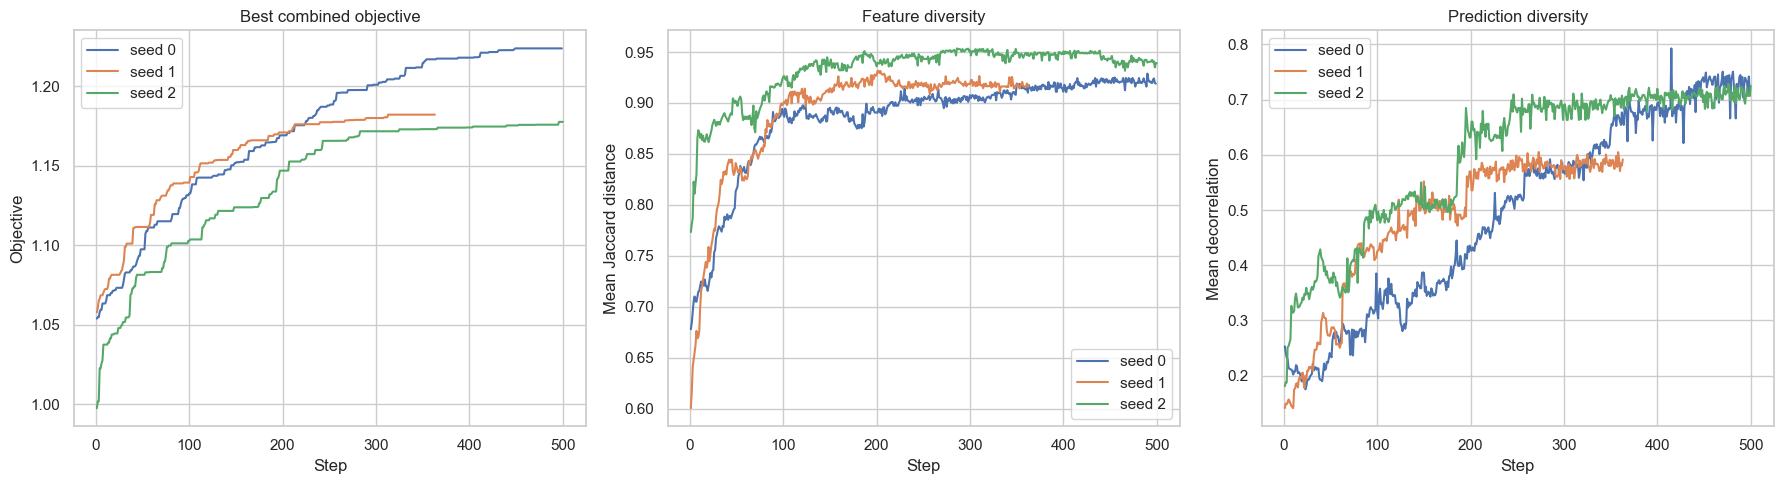

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for seed in INNER_SEEDS:
    values = diversity_history.query("seed == @seed")
    axes[0].plot(values["step"], values["best_accepted_objective"], label=f"seed {seed}")
    axes[1].plot(values["step"], values["feature_diversity"], label=f"seed {seed}")
    axes[2].plot(values["step"], values["prediction_diversity"], label=f"seed {seed}")
axes[0].set(title="Best combined objective", xlabel="Step", ylabel="Objective")
axes[1].set(title="Feature diversity", xlabel="Step", ylabel="Mean Jaccard distance")
axes[2].set(title="Prediction diversity", xlabel="Step", ylabel="Mean decorrelation")
for axis in axes:
    axis.legend()
plt.tight_layout()